## Setup

In [1]:
from microbiome_gpt.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [ ]:
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=RuntimeWarning, module="skbio")

In [3]:
from microbiome_gpt.utils.project_paths import find_data_path, find_figures_path

data_path = find_data_path()
figures_path = find_figures_path()
figures_path.mkdir(parents=True, exist_ok=True)

## Read Data

In [4]:
output_path = find_data_path().parent / "output"

# Training history
training_stats = pd.read_csv(f"{output_path}/training_stats_sample.csv", index_col=0)

# True values (from data directory)
taxonomy_true = pd.read_csv(f"{data_path}/taxonomy_sample.csv", index_col=0).sort_index()
pathways_true = pd.read_csv(f"{data_path}/pathways_sample.csv", index_col=0).sort_index()

# Predicted values (from output directory)
taxonomy_pred = pd.read_csv(f"{output_path}/pred_taxonomy_sample.csv", index_col=0).sort_index()
pathways_pred = pd.read_csv(f"{output_path}/pred_pathways_sample.csv", index_col=0).sort_index()

print(f"training_stats: {training_stats.shape}")
print(f"taxonomy_true:  {taxonomy_true.shape} | taxonomy_pred: {taxonomy_pred.shape}")
print(f"pathways_true:  {pathways_true.shape} | pathways_pred: {pathways_pred.shape}")

training_stats: (55, 6)
taxonomy_true:  (128, 202) | taxonomy_pred: (128, 202)
pathways_true:  (128, 398) | pathways_pred: (128, 398)


# Figure 1B-1 - Training History

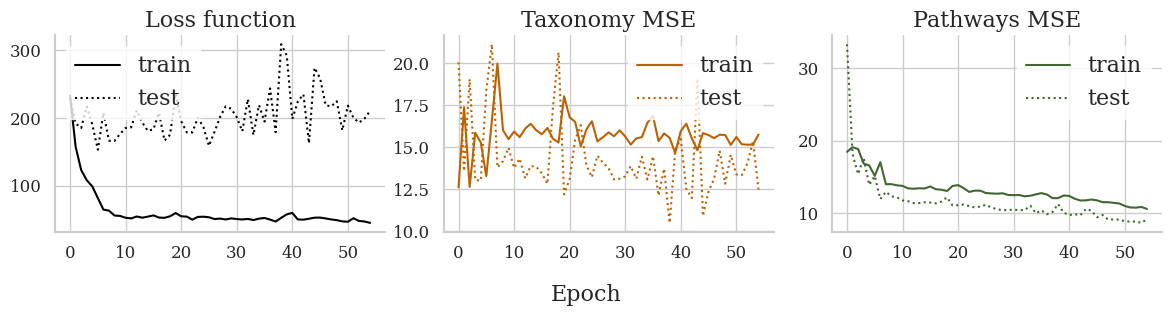

In [5]:
metrics = [
    ('train_loss',         'test_loss',         'Loss function', 'black'),
    ('train_taxonomy_mse', 'test_taxonomy_mse', 'Taxonomy MSE',  '#bd6100ff'),
    ('train_pathways_mse', 'test_pathways_mse', 'Pathways MSE',  '#426632ff'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, (train_col, test_col, title, color) in zip(axes, metrics):
    sns.lineplot(data=training_stats, x='epoch', y=train_col, label='train', ax=ax, c=color)
    sns.lineplot(data=training_stats, x='epoch', y=test_col, label='test', ax=ax, c=color, linestyle=':')
    ax.set_title(title)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.legend(edgecolor='w')

sns.despine(left=False, right=True, top=True, bottom=False)
fig.text(0.5, -0.05, 'Epoch', ha='center')

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1B1.png", dpi=300)

# Figure 1B-2 - Reconstruction PCoA

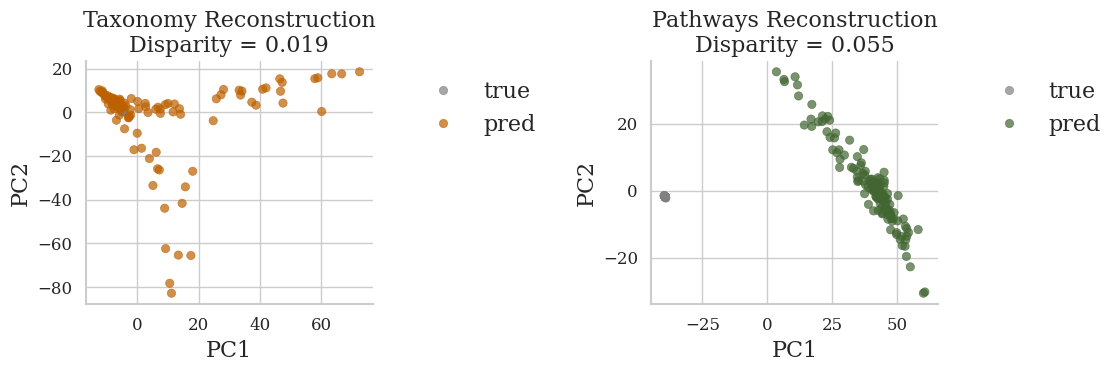

In [6]:
from microbiome_gpt.utils.analysis import get_pcoa_coords, get_disparity

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

taxonomy_coords = get_pcoa_coords(taxonomy_true, taxonomy_pred)
labels = ['true'] * len(taxonomy_true) + ['pred'] * len(taxonomy_pred)
sns.scatterplot(x=taxonomy_coords.PC1, y=taxonomy_coords.PC2,
                hue=labels, alpha=0.7, edgecolor=None,
                palette={'true': 'grey', 'pred': '#bd6100ff'},
                ax=axes[0])

disp_t = round(get_disparity(taxonomy_true, taxonomy_pred), 3)
axes[0].set_title(f'Taxonomy Reconstruction\nDisparity = {disp_t}')
axes[0].legend(edgecolor='w', bbox_to_anchor=(1.1, 1))

pathways_coords = get_pcoa_coords(pathways_true, pathways_pred)
labels = ['true'] * len(pathways_true) + ['pred'] * len(pathways_pred)
sns.scatterplot(x=pathways_coords.PC1, y=pathways_coords.PC2,
                hue=labels, alpha=0.7, edgecolor=None,
                palette={'true': 'grey', 'pred': '#426632ff'},
                ax=axes[1])

disp_p = round(get_disparity(pathways_true, pathways_pred), 3)
axes[1].set_title(f'Pathways Reconstruction\nDisparity = {disp_p}')
axes[1].legend(edgecolor='w', bbox_to_anchor=(1.1, 1))

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1B2.png", dpi=300)

# Figure 1B-3 - Reconstruction Scatter

In [9]:
def reconstruction_scatter(ax, true_df, pred_df, title):
    true_vals = true_df.values.flatten()
    pred_vals = pred_df.values.flatten()

    ax.plot(pred_vals, true_vals, 'o', c='grey', markersize=2, alpha=0.6)

    min_val = min(pred_vals.min(), true_vals.min())
    max_val = max(pred_vals.max(), true_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

    ax.set_xlabel('Reconstructed')
    ax.set_ylabel('Original')
    ax.set_title(title)

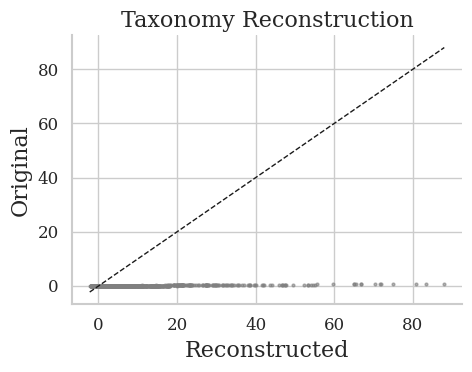

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
reconstruction_scatter(ax, taxonomy_true, taxonomy_pred, 'Taxonomy Reconstruction')
sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1B3.png", dpi=300)

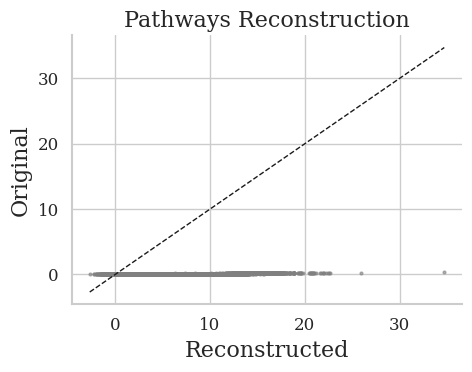

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
reconstruction_scatter(ax, pathways_true, pathways_pred, 'Pathways Reconstruction')
sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1B4.png", dpi=300)